## Importing libraries

In [17]:
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import xgboost as xgb
from sklearn.neighbors import KNeighborsClassifier
import pickle as pl
from sklearn.base import clone

/home/aditya/miniconda3/envs/myenv/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


## Defining the model

In [22]:
output_dir = "./4_2e-05_quad"

In [23]:
# Load data
alignment_matrix = np.load(f"{output_dir }/alignment_matrix_M.npy")
with open(f"{output_dir}/predictions.json", 'r') as file:
    data = json.load(file)
ground_truth = np.array(data["indicator_vector_true"])

# Define models with expanded set
models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    "KNN": KNeighborsClassifier()
}

# Parameter grids for grid search
param_grids = {
    "Logistic Regression": {
        'logisticregression__C': [0.1, 1, 10],
        'logisticregression__penalty': ['l2'],
        'logisticregression__solver': ['lbfgs','liblinear'],
        'logisticregression__max_iter': [500, 1000, 2000]
    },
    "SVM": {
        'svc__C': [0.1, 1, 10],
        'svc__gamma': ['scale', 'auto', 0.1, 0.01],
        'svc__kernel': ['rbf','poly','sigmoid'],
        'svc__degree': [2,3,4,5]
    },
    
    "Random Forest": {
        'randomforestclassifier__n_estimators': [100, 200, 300,500],
        'randomforestclassifier__max_depth': [None, 10, 15,20,25],
        'randomforestclassifier__min_samples_split': [3, 5],
        'randomforestclassifier__max_features': ['sqrt', 'log2', 0.5] # Feature subsampling
    },
    
    # no "no_of_iterations" required.
    "Gradient Boosting": {
        'gradientboostingclassifier__n_estimators': [100, 200,300,500],
        'gradientboostingclassifier__learning_rate': [0.01, 0.03,0.1],
        'gradientboostingclassifier__max_depth': [None,10, 15,20,25]
    },
    "XGBoost": {
        'xgbclassifier__n_estimators': [100, 200,300,500],
        'xgbclassifier__learning_rate': [0.01, 0.03,0.1],
        'xgbclassifier__max_depth': [None,10, 15,20,25]
    },
    
    "KNN": {    
    'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11, 15],
    'kneighborsclassifier__weights': ['uniform', 'distance'],
    'kneighborsclassifier__metric': ['euclidean', 'manhattan', 'minkowski'],
    'kneighborsclassifier__p': [1, 2]  # For minkowski metric
    }
}

## Getting the bestmodel through cross validation and the corresponding results

In [ ]:
def store_results(name,grid_search,results):
# The refitted estimator is made available at the best_estimator_
# refit=True (the default) retrains the best-performing model on the entire training dataset after the cross-validation process is complete. 
# selecting the combination with the highest average performance metric (e.g., accuracy) across all folds
    result = {}
    metrics = {}
    best_index = grid_search.best_index_
    metrics['accuracy'] = (grid_search.cv_results_['mean_test_accuracy'][best_index],grid_search.cv_results_['std_test_accuracy'][best_index])
    metrics['f1'] = (grid_search.cv_results_['mean_test_f1'][best_index],grid_search.cv_results_['std_test_f1'][best_index])
    metrics['precison'] = (grid_search.cv_results_['mean_test_precision'][best_index],grid_search.cv_results_['std_test_precision'][best_index])
    metrics['recall'] = (grid_search.cv_results_['mean_test_recall'][best_index],grid_search.cv_results_['std_test_recall'][best_index])
    metrics['roc_auc'] = (grid_search.cv_results_['mean_test_roc_auc'][best_index],grid_search.cv_results_['std_test_roc_auc'][best_index])
    result['metrics'] = metrics
    result['params'] = grid_search.best_params_
    result['untrained_model'] = clone(grid_search.best_estimator_)
    results[name] = result

In [ ]:
# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate models with grid search
results = {}
best_estimators = {}
for name, model in models.items():
    print(f"\nTraining {name} with GridSearchCV...")
    pipe = make_pipeline(StandardScaler(), model)
    grid_search = GridSearchCV(pipe, param_grid=param_grids[name], cv=cv, scoring=["accuracy", "f1", "precision", "recall", "roc_auc"], n_jobs=-1,refit='f1')
    grid_search.fit(alignment_matrix, ground_truth)
    store_results(name,grid_search,results)

In [ ]:
# store results 
with open('./results_4_2e-05_model_baseline.pkl','wb') as f:
    pl.dump(results,f)

In [18]:
with open('./results_4_2e-05_quad.pkl','rb') as f:
    results = pl.load(f)

In [26]:
results

{'Logistic Regression': {'metrics': {'accuracy': (0.5074,
    0.007364781055808794),
   'f1': (0.5026159207026848, 0.009246300864752529),
   'precison': (0.5076606865417418, 0.007890603652617149),
   'recall': (0.49800000000000005, 0.016443843832875588),
   'roc_auc': (0.5131176, 0.008256892819941415)},
  'params': {'logisticregression__C': 10,
   'logisticregression__max_iter': 500,
   'logisticregression__penalty': 'l2',
   'logisticregression__solver': 'liblinear'},
  'untrained_model': Pipeline(steps=[('standardscaler', StandardScaler()),
                  ('logisticregression',
                   LogisticRegression(C=10, max_iter=500, solver='liblinear'))])},
 'SVM': {'metrics': {'accuracy': (0.5022, 0.0165698521417664),
   'f1': (0.513456173032176, 0.038562871605561176),
   'precison': (0.5006984285378142, 0.017169916099776323),
   'recall': (0.5288000000000002, 0.05999466642960856),
   'roc_auc': (0.501656, 0.02048826411387748)},
  'params': {'svc__C': 0.1,
   'svc__degree': 2,


In [19]:
# Print results
print("\nModel performance (mean ± std):")
for name in results:
    metrics = results[name]['metrics']
    print(f"\n{name}:")
    for metric, (mean_val, std_val) in metrics.items():
        print(f"  {metric:10s}: {mean_val:.3f} ± {std_val:.3f}")


Model performance (mean ± std):

Logistic Regression:
  accuracy  : 0.507 ± 0.007
  f1        : 0.503 ± 0.009
  precison  : 0.508 ± 0.008
  recall    : 0.498 ± 0.016
  roc_auc   : 0.513 ± 0.008

SVM:
  accuracy  : 0.502 ± 0.017
  f1        : 0.513 ± 0.039
  precison  : 0.501 ± 0.017
  recall    : 0.529 ± 0.060
  roc_auc   : 0.502 ± 0.020

Random Forest:
  accuracy  : 0.530 ± 0.011
  f1        : 0.526 ± 0.015
  precison  : 0.531 ± 0.011
  recall    : 0.521 ± 0.020
  roc_auc   : 0.527 ± 0.013

Gradient Boosting:
  accuracy  : 0.517 ± 0.011
  f1        : 0.518 ± 0.010
  precison  : 0.517 ± 0.011
  recall    : 0.520 ± 0.008
  roc_auc   : 0.520 ± 0.010

XGBoost:
  accuracy  : 0.521 ± 0.015
  f1        : 0.524 ± 0.014
  precison  : 0.521 ± 0.015
  recall    : 0.527 ± 0.018
  roc_auc   : 0.522 ± 0.019

KNN:
  accuracy  : 0.524 ± 0.013
  f1        : 0.522 ± 0.015
  precison  : 0.525 ± 0.013
  recall    : 0.520 ± 0.017
  roc_auc   : 0.518 ± 0.021


In [20]:
# Pick best model by F1 score
best_model_name = max(results, key=lambda k: results[k]['metrics']["f1"][0])
print(f"\nBest model based on F1 score: {best_model_name}")
print(f"\nParams of best model: {results[best_model_name]['params']} ")


Best model based on F1 score: Random Forest

Params of best model: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__min_samples_split': 3, 'randomforestclassifier__n_estimators': 100} 


## Getting the test scores for the model

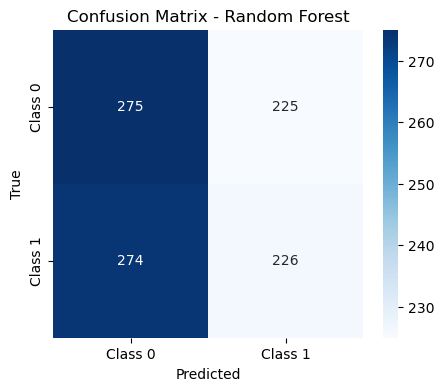


Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.55      0.52       500
           1       0.50      0.45      0.48       500

    accuracy                           0.50      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       0.50      0.50      0.50      1000



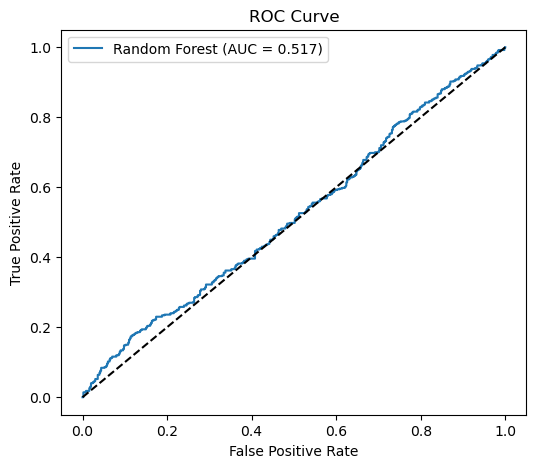

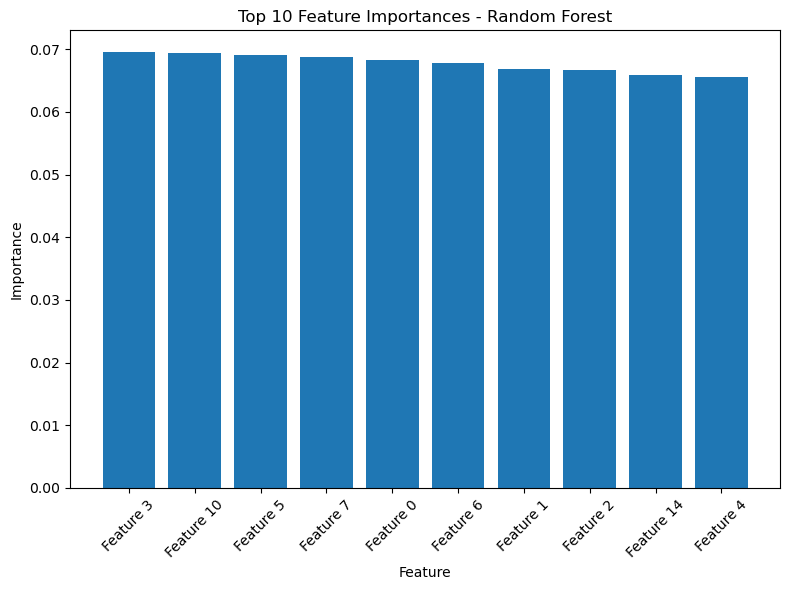

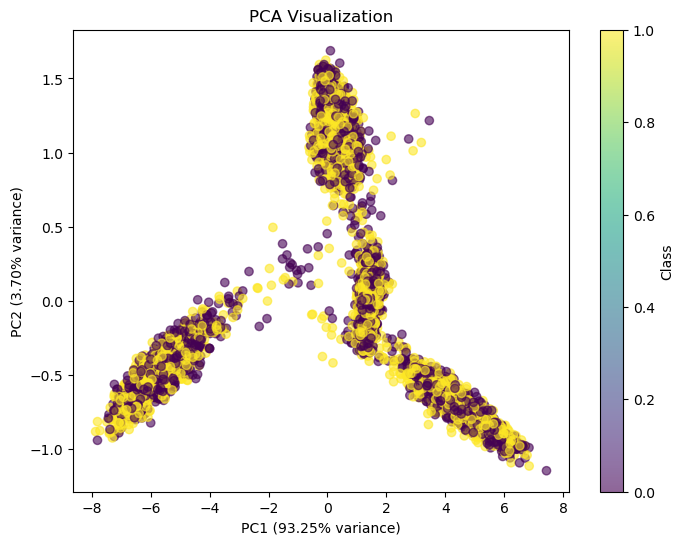

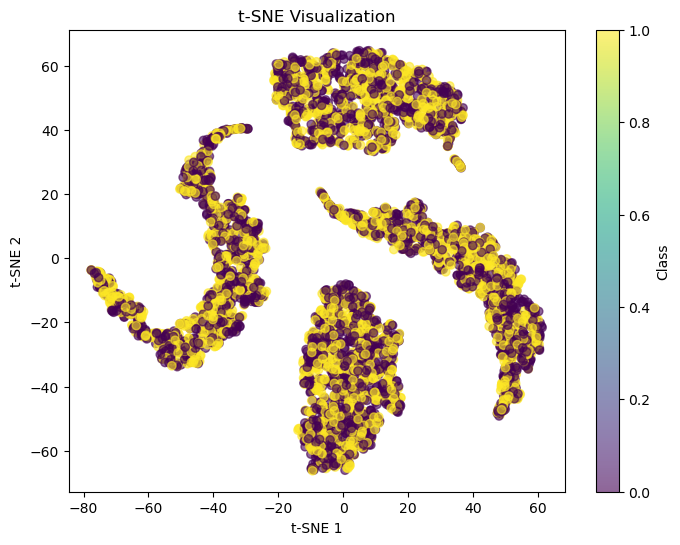

In [30]:
# Train/test split for final evaluation
X_train, X_test, y_train, y_test = train_test_split(alignment_matrix, ground_truth,
                                                    test_size=0.2, stratify=ground_truth,
                                                    random_state=42)

# Train best model
best_model = results[best_model_name]['untrained_model']
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc_score(y_test, y_prob):.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Feature importance for tree-based models
if best_model_name in ["Random Forest", "Gradient Boosting", "XGBoost"]:
    model_step = best_model.steps[-1][1]  # Much simpler!
    importances = model_step.feature_importances_
    indices = np.argsort(importances)[::-1]
    plt.figure(figsize=(8,6))
    plt.bar(range(10), importances[indices[:10]], align="center")
    plt.xticks(range(10), [f"Feature {i}" for i in indices[:10]], rotation=45)
    plt.title(f"Top 10 Feature Importances - {best_model_name}")
    plt.xlabel("Feature")
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.show()

# PCA Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(StandardScaler().fit_transform(alignment_matrix))
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=ground_truth, cmap='viridis', alpha=0.6)
plt.title("PCA Visualization")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
plt.colorbar(scatter, label='Class')
plt.show()

# t-SNE Visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(StandardScaler().fit_transform(alignment_matrix))
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=ground_truth, cmap='viridis', alpha=0.6)
plt.title("t-SNE Visualization")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, label='Class')
plt.show()